In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

### Loading the Dataset

In [76]:
df= pd.read_csv('3.1-data-sheet-guvi-courses.csv')
df.head(5)

,course_id,course_title,url,price,num_subscribers,num_reviews,num_lectures,level,Rating,content_duration,published_timestamp,subject
0,41295.0,Learn HTML5 Programming From Scratch,https://www.udemy.com/learn-html5-programming-...,0.0,268923.0,8629.0,45.0,Beginner Level,0.82,10.5,2013-02-14T07:03:41Z,Subject: Web Development
1,59014.0,Coding for Entrepreneurs Basic,https://www.udemy.com/coding-for-entrepreneurs...,0.0,161029.0,279.0,27.0,Expert Level,0.69,3.5,2013-06-09T15:51:55Z,Subject: Web Development
2,625204.0,The Web Developer Bootcamp,https://www.udemy.com/the-web-developer-bootcamp/,200.0,121584.0,27445.0,342.0,Beginner Level,0.89,43.0,2015-11-02T21:13:27Z,Subject: Web Development
3,173548.0,Build Your First Website in 1 Week with HTML5 ...,https://www.udemy.com/build-your-first-website...,0.0,120291.0,5924.0,30.0,All Levels,0.78,3.0,2014-04-08T16:21:30Z,Subject: Web Development
4,764164.0,The Complete Web Developer Course 2.0,https://www.udemy.com/the-complete-web-develop...,200.0,114512.0,22412.0,304.0,Beginner Level,0.55,30.5,2016-03-08T22:28:36Z,Subject: Web Development


##### Dropped high-cardinality text and ID columns that do not contribute predictive value to the machine learning model

In [77]:
df.drop(['course_id','course_title','url'],axis=1,inplace=True)
df.head(5)

,price,num_subscribers,num_reviews,num_lectures,level,Rating,content_duration,published_timestamp,subject
0,0.0,268923.0,8629.0,45.0,Beginner Level,0.82,10.5,2013-02-14T07:03:41Z,Subject: Web Development
1,0.0,161029.0,279.0,27.0,Expert Level,0.69,3.5,2013-06-09T15:51:55Z,Subject: Web Development
2,200.0,121584.0,27445.0,342.0,Beginner Level,0.89,43.0,2015-11-02T21:13:27Z,Subject: Web Development
3,0.0,120291.0,5924.0,30.0,All Levels,0.78,3.0,2014-04-08T16:21:30Z,Subject: Web Development
4,200.0,114512.0,22412.0,304.0,Beginner Level,0.55,30.5,2016-03-08T22:28:36Z,Subject: Web Development


### Dropped Duplicated Rows

In [78]:
df.drop_duplicates(inplace=True)

#### Checking the dataframe that contains Null Values

In [79]:
df.isnull().sum()

price                  2
num_subscribers        2
num_reviews            2
num_lectures           2
level                  2
Rating                 2
content_duration       2
published_timestamp    2
subject                1
dtype: int64

#### Dropped the missing rows because they made up less than 3% of the data, so removing them won't affect our model's performance

In [80]:
df.dropna(inplace=True)

In [81]:
df.isnull().sum()

price                  0
num_subscribers        0
num_reviews            0
num_lectures           0
level                  0
Rating                 0
content_duration       0
published_timestamp    0
subject                0
dtype: int64

In [82]:
df.info()

<class 'pandas.DataFrame'>
Index: 3676 entries, 0 to 3679
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   price                3676 non-null   float64
 1   num_subscribers      3676 non-null   float64
 2   num_reviews          3676 non-null   float64
 3   num_lectures         3676 non-null   float64
 4   level                3676 non-null   str    
 5   Rating               3676 non-null   float64
 6   content_duration     3676 non-null   float64
 7   published_timestamp  3676 non-null   str    
 8   subject              3676 non-null   str    
dtypes: float64(6), str(3)
memory usage: 287.2 KB


### Broke down the published timestamp into separate year, month, and day columns

In [83]:
# Convert published_timestamp to datetime
df['published_timestamp'] = pd.to_datetime(df['published_timestamp'])

# Extract useful features
df['published_year'] = df['published_timestamp'].dt.year
df['published_month'] = df['published_timestamp'].dt.month
df['published_day'] = df['published_timestamp'].dt.day

#### Dropped published_timestamp after Extration

In [84]:
df.drop(['published_timestamp'],axis=1,inplace=True)

In [85]:
df.head()

,price,num_subscribers,num_reviews,num_lectures,level,Rating,content_duration,subject,published_year,published_month,published_day
0,0.0,268923.0,8629.0,45.0,Beginner Level,0.82,10.5,Subject: Web Development,2013,2,14
1,0.0,161029.0,279.0,27.0,Expert Level,0.69,3.5,Subject: Web Development,2013,6,9
2,200.0,121584.0,27445.0,342.0,Beginner Level,0.89,43.0,Subject: Web Development,2015,11,2
3,0.0,120291.0,5924.0,30.0,All Levels,0.78,3.0,Subject: Web Development,2014,4,8
4,200.0,114512.0,22412.0,304.0,Beginner Level,0.55,30.5,Subject: Web Development,2016,3,8


In [86]:
df.info()

<class 'pandas.DataFrame'>
Index: 3676 entries, 0 to 3679
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             3676 non-null   float64
 1   num_subscribers   3676 non-null   float64
 2   num_reviews       3676 non-null   float64
 3   num_lectures      3676 non-null   float64
 4   level             3676 non-null   str    
 5   Rating            3676 non-null   float64
 6   content_duration  3676 non-null   float64
 7   subject           3676 non-null   str    
 8   published_year    3676 non-null   int32  
 9   published_month   3676 non-null   int32  
 10  published_day     3676 non-null   int32  
dtypes: float64(6), int32(3), str(2)
memory usage: 301.5 KB


In [87]:
df.level.value_counts()

level
All Levels            1925
Beginner Level        1271
Intermediate Level     422
Expert Level            58
Name: count, dtype: int64

In [88]:
df.level.value_counts()

level
All Levels            1925
Beginner Level        1271
Intermediate Level     422
Expert Level            58
Name: count, dtype: int64

In [89]:
num_feature = df.select_dtypes(exclude='object').columns
num_feature

Index(['price', 'num_subscribers', 'num_reviews', 'num_lectures', 'Rating',
       'content_duration', 'published_year', 'published_month',
       'published_day'],
      dtype='str')

In [90]:
df[num_feature].corr()

,price,num_subscribers,num_reviews,num_lectures,Rating,content_duration,published_year,published_month,published_day
price,1.000000,0.050555,0.113423,0.330233,0.031643,0.293245,0.134875,0.037615,0.012244
num_subscribers,0.050555,1.000000,0.650761,0.158092,-0.007353,0.161844,-0.182635,0.016482,0.007271
num_reviews,0.113423,0.650761,1.000000,0.242986,0.004137,0.228842,-0.053045,0.007100,-0.003432
num_lectures,0.330233,0.158092,0.242986,1.000000,-0.037170,0.801630,-0.024659,0.031695,-0.006290
Rating,0.031643,-0.007353,0.004137,-0.037170,1.000000,0.000650,0.059683,-0.052142,0.029443
content_duration,0.293245,0.161844,0.228842,0.801630,0.000650,1.000000,-0.058449,0.020909,-0.002023
published_year,0.134875,-0.182635,-0.053045,-0.024659,0.059683,-0.058449,1.000000,-0.290066,-0.019506
published_month,0.037615,0.016482,0.007100,0.031695,-0.052142,0.020909,-0.290066,1.000000,0.015861
published_day,0.012244,0.007271,-0.003432,-0.006290,0.029443,-0.002023,-0.019506,0.015861,1.000000


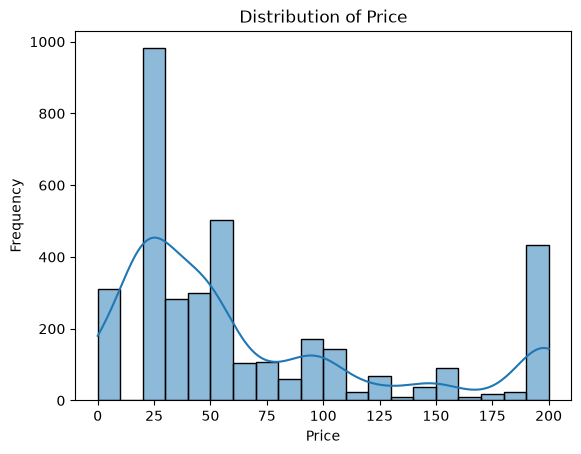

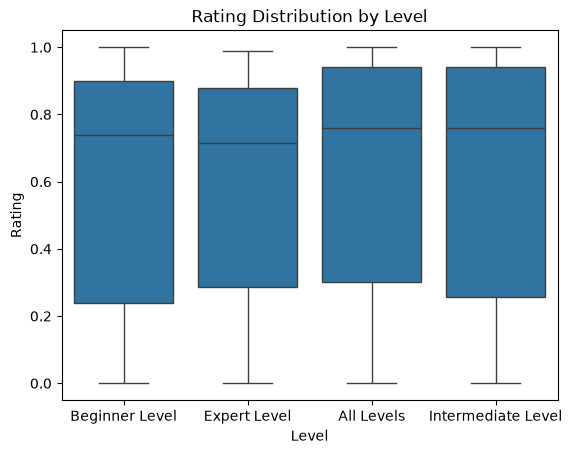

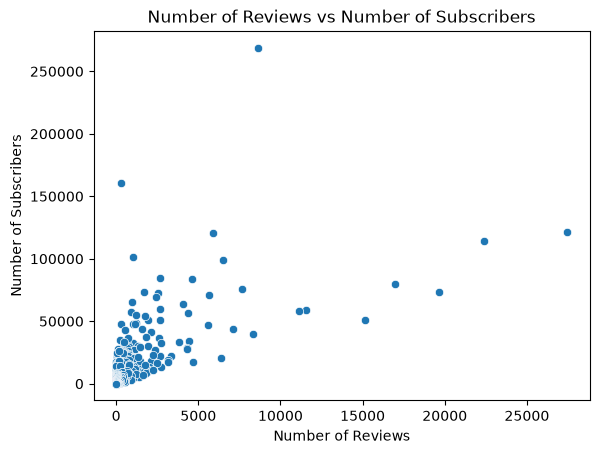

In [91]:
# Histograms of numerical features
sns.histplot(df['price'], bins=20, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

# Box plot of 'Rating' grouped by 'level'
sns.boxplot(x=df['level'], y=df['Rating'])
plt.title('Rating Distribution by Level')
plt.xlabel('Level')
plt.ylabel('Rating')
plt.show()

# Scatter plot of 'num_reviews' vs 'num_subscribers'
sns.scatterplot(x=df['num_reviews'], y=df['num_subscribers'])
plt.title('Number of Reviews vs Number of Subscribers')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Subscribers')
plt.show()

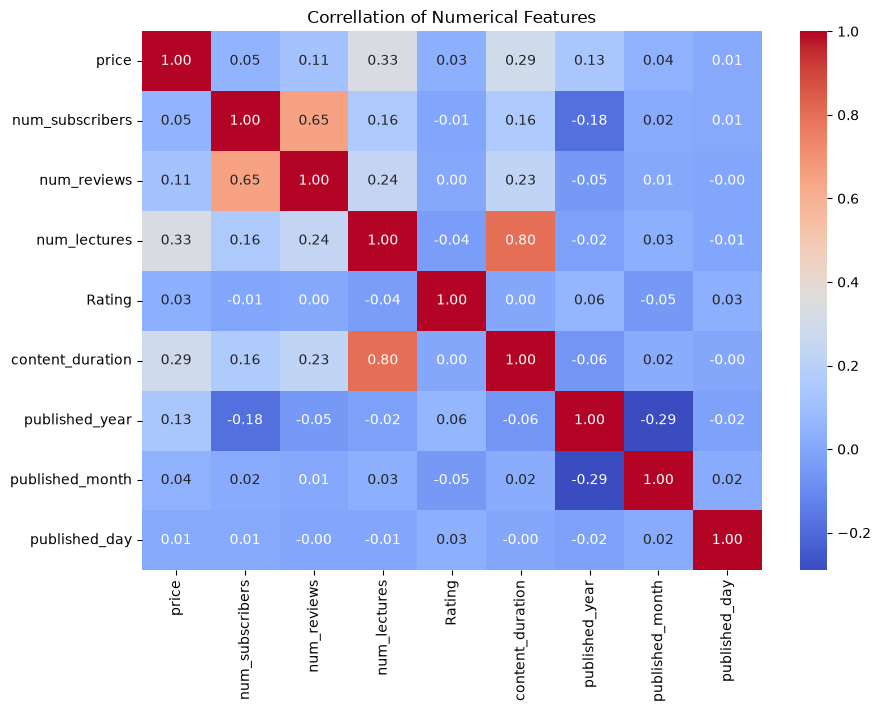

In [92]:
plt.figure(figsize=(10,7))
sns.heatmap(df[num_feature].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correllation of Numerical Features")
plt.show()

In [93]:
df.drop(['published_month','published_day','num_lectures'],axis=1,inplace=True)

### 🔎 Feature Dropping Insight

In the data cleaning stage, some columns were removed to keep the dataset lean and avoid redundancy:
- **published_month, published_day** → weak correlation with ratings; seasonal publishing trends are not significant for course quality.  
- **num_lectures vs content_duration** → highly correlated (~0.8). Keeping both introduces multicollinearity.  
  - Decision: retain **content_duration** (more interpretable) and drop **num_lectures**.  

This ensures the model focuses on meaningful predictors like **price, subscribers, reviews, level, subject, and published_year/course_age**, while avoiding noise and redundancy.


In [94]:
df.head(5)

,price,num_subscribers,num_reviews,level,Rating,content_duration,subject,published_year
0,0.0,268923.0,8629.0,Beginner Level,0.82,10.5,Subject: Web Development,2013
1,0.0,161029.0,279.0,Expert Level,0.69,3.5,Subject: Web Development,2013
2,200.0,121584.0,27445.0,Beginner Level,0.89,43.0,Subject: Web Development,2015
3,0.0,120291.0,5924.0,All Levels,0.78,3.0,Subject: Web Development,2014
4,200.0,114512.0,22412.0,Beginner Level,0.55,30.5,Subject: Web Development,2016


In [95]:
from sklearn.preprocessing import LabelEncoder
level_encoder = LabelEncoder()
subject_encoder = LabelEncoder()

In [96]:
df['level']=level_encoder.fit_transform(df['level'])
df['subject']=subject_encoder.fit_transform(df['subject'])

In [97]:
df.head()

,price,num_subscribers,num_reviews,level,Rating,content_duration,subject,published_year
0,0.0,268923.0,8629.0,1,0.82,10.5,3,2013
1,0.0,161029.0,279.0,2,0.69,3.5,3,2013
2,200.0,121584.0,27445.0,1,0.89,43.0,3,2015
3,0.0,120291.0,5924.0,0,0.78,3.0,3,2014
4,200.0,114512.0,22412.0,1,0.55,30.5,3,2016


In [98]:
X=df.drop(['Rating'],axis=1)
y=df['Rating']

In [99]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [100]:
X_train.shape

(2940, 7)

In [101]:
y_train.shape

(2940,)

In [102]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
X_train=scalar.fit_transform(X_train)
X_test=scalar.transform(X_test)

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from xgboost import XGBRegressor

In [104]:
def evaluation_metric(true,predicted):
    mse = mean_squared_error(true,predicted)
    ame =mean_absolute_error(true,predicted)
    rmse=np.sqrt(mse)
    r2_square = r2_score(true,predicted)
    return mse,ame,rmse,r2_square

In [105]:
models={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge": Ridge(),
    "K-Neighbours Regressor":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest Regressor":RandomForestRegressor(),
    "XGB Regressor":XGBRegressor(),
    "Ada boost Regressor":AdaBoostRegressor()
}

model_list=[]
r2_list=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mse,model_train_ame,model_train_rmse,model_train_r2=evaluation_metric(y_train,y_train_pred)
    model_test_mse,model_test_ame,model_test_rmse,model_test_r2=evaluation_metric(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance of Training Set")
    print("Mean Squared Error : {:.4f}".format(model_train_mse))
    print("Root Mean Squared Error : {:.4f}".format(model_train_rmse))
    print("Mean Absolute Error : {:.4f}".format(model_train_ame))
    print("R2 Score : {:.4f}".format(model_train_r2))

    print("----------------------------------------")
    print("Model Performance of Test Set")
    print("Mean Squared Error : {:.4f}".format(model_test_mse))
    print("Root Mean Squared Error : {:.4f}".format(model_test_rmse))
    print("Mean Absolute Error : {:.4f}".format(model_test_ame))
    print("R2 Score : {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print("="*39)
    print('\n')

Linear Regression
Model Performance of Training Set
Mean Squared Error : 0.1091
Root Mean Squared Error : 0.3302
Mean Absolute Error : 0.2964
R2 Score : 0.0263
----------------------------------------
Model Performance of Test Set
Mean Squared Error : 0.1072
Root Mean Squared Error : 0.3275
Mean Absolute Error : 0.2913
R2 Score : 0.0259


Lasso
Model Performance of Training Set
Mean Squared Error : 0.1120
Root Mean Squared Error : 0.3347
Mean Absolute Error : 0.3023
R2 Score : 0.0000
----------------------------------------
Model Performance of Test Set
Mean Squared Error : 0.1107
Root Mean Squared Error : 0.3327
Mean Absolute Error : 0.2971
R2 Score : -0.0055


Ridge
Model Performance of Training Set
Mean Squared Error : 0.1091
Root Mean Squared Error : 0.3302
Mean Absolute Error : 0.2964
R2 Score : 0.0263
----------------------------------------
Model Performance of Test Set
Mean Squared Error : 0.1072
Root Mean Squared Error : 0.3275
Mean Absolute Error : 0.2913
R2 Score : 0.0259




In [106]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Random Forest parameters (lightweight)
rf_params = {
    "n_estimators": [100, 200, 300],       # number of trees
    "max_depth": [None, 5, 10, 15],        # depth of trees
    "min_samples_split": [2, 5, 10],       # minimum samples to split
    "min_samples_leaf": [1, 2, 4],         # minimum samples per leaf
}

rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_params,
    n_iter=10,              # keep iterations small for laptop
    cv=3,                   # 3-fold CV
    verbose=2,
    n_jobs=-1               # use all cores
)

rf_random.fit(X_train, y_train)
print("Best RF Params:", rf_random.best_params_)
print("Best RF Score:", rf_random.best_score_)


# XGB parameters (lightweight)
xgb_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_random = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=xgb_params,
    n_iter=10,              # small search space
    cv=3,
    verbose=2,
    n_jobs=-1
)

xgb_random.fit(X_train, y_train)

print("Best XGB Params:", xgb_random.best_params_)
print("Best XGB Score:", xgb_random.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 15}
Best RF Score: 0.35586896350598596
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGB Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best XGB Score: 0.3258644793422088


In [108]:
models={
    "Random Forest Regressor":RandomForestRegressor(n_estimators= 200, min_samples_split= 2, min_samples_leaf= 4, max_depth=15),
    "XGB Regressor":XGBRegressor(subsample= 1, n_estimators= 200, max_depth= 7, learning_rate= 0.01, colsample_bytree= 1.0)
}

model_list1=[]
r2_list1=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mse,model_train_ame,model_train_rmse,model_train_r2=evaluation_metric(y_train,y_train_pred)
    model_test_mse,model_test_ame,model_test_rmse,model_test_r2=evaluation_metric(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list1.append(list(models.keys())[i])

    print("Model Performance of Training Set")
    print("Mean Squared Error : {:.4f}".format(model_train_mse))
    print("Root Mean Squared Error : {:.4f}".format(model_train_rmse))
    print("Mean Absolute Error : {:.4f}".format(model_train_ame))
    print("R2 Score : {:.4f}".format(model_train_r2))

    print("----------------------------------------")
    print("Model Performance of Test Set")
    print("Mean Squared Error : {:.4f}".format(model_test_mse))
    print("Root Mean Squared Error : {:.4f}".format(model_test_rmse))
    print("Mean Absolute Error : {:.4f}".format(model_test_ame))
    print("R2 Score : {:.4f}".format(model_test_r2))
    r2_list1.append(model_test_r2)

    print("="*39)
    print('\n')

Random Forest Regressor
Model Performance of Training Set
Mean Squared Error : 0.0309
Root Mean Squared Error : 0.1759
Mean Absolute Error : 0.1316
R2 Score : 0.7238
----------------------------------------
Model Performance of Test Set
Mean Squared Error : 0.0672
Root Mean Squared Error : 0.2592
Mean Absolute Error : 0.1969
R2 Score : 0.3897


XGB Regressor
Model Performance of Training Set
Mean Squared Error : 0.0501
Root Mean Squared Error : 0.2237
Mean Absolute Error : 0.1860
R2 Score : 0.5530
----------------------------------------
Model Performance of Test Set
Mean Squared Error : 0.0706
Root Mean Squared Error : 0.2656
Mean Absolute Error : 0.2181
R2 Score : 0.3591




### 📊 Model Evaluation Insight

**Without tuning:**
- Linear models (Linear Regression, Ridge, Lasso) → Very weak R² (~0.02 or lower).  
- KNN & Decision Tree → Strong training fit but collapse on test → clear **overfitting**.  
- Random Forest & XGB → Best among all, but test R² still modest (~0.36 and ~0.29).  
- AdaBoost → Moderate but weaker (~0.20 test R²).

**With tuning (RandomizedSearchCV):**
- **Random Forest Regressor**  
  - Train R² ≈ **0.72**  
  - Test R² ≈ **0.39**  
  - Best generalization, balanced bias–variance tradeoff.  
- **XGB Regressor**  
  - Train R² ≈ **0.55**  
  - Test R² ≈ **0.36**  
  - Strong alternative, but slightly weaker than Random Forest.  

**Conclusion:**  
- Random Forest is the most reliable model for predicting course ratings in this dataset.  
- XGB is a close second.  
- Hyperparameter tuning clearly improved generalization compared to baseline runs.